# A3. Анализ HyperLogLog


Данные для анализа были сгенерированы при помощи ранее написанных классов HyperLogLog, HashFuncGen, RandomStreamGen и находятся в папке files проекта A3.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


## Этап 1. Инфраструктура

Проверим что выдаваемые хеш-функцией значения распределены равномерно, для этого используем формулу матожидания бернуллиевской случайной величины и сравниваем с нашими значениями:

In [32]:
hash_df = pd.read_csv('hash_uniformity.csv')

expected = hash_df['count'].sum() / len(hash_df)
chi_squared = ((hash_df['count'] - expected) ** 2 / expected).sum()

print(f"Всего элементов: {hash_df['count'].sum()}")
print(f"Число бакетов: {len(hash_df)}")
print(f"Ожидаемое среднее: {expected:.1f}")
print(f"Фактическое среднее: {hash_df['count'].mean():.1f}")
print(f"Стд. отклонение: {hash_df['count'].std():.1f}")
print(f"Хи-квадрат: {chi_squared:.2f}")
print(f"Критическое значение (df=255, α=0.05): 293.2")

Всего элементов: 100000
Число бакетов: 256
Ожидаемое среднее: 390.6
Фактическое среднее: 390.6
Стд. отклонение: 19.8
Хи-квадрат: 255.05
Критическое значение (df=255, α=0.05): 293.2


Построим графики по данным для визуальной оценки

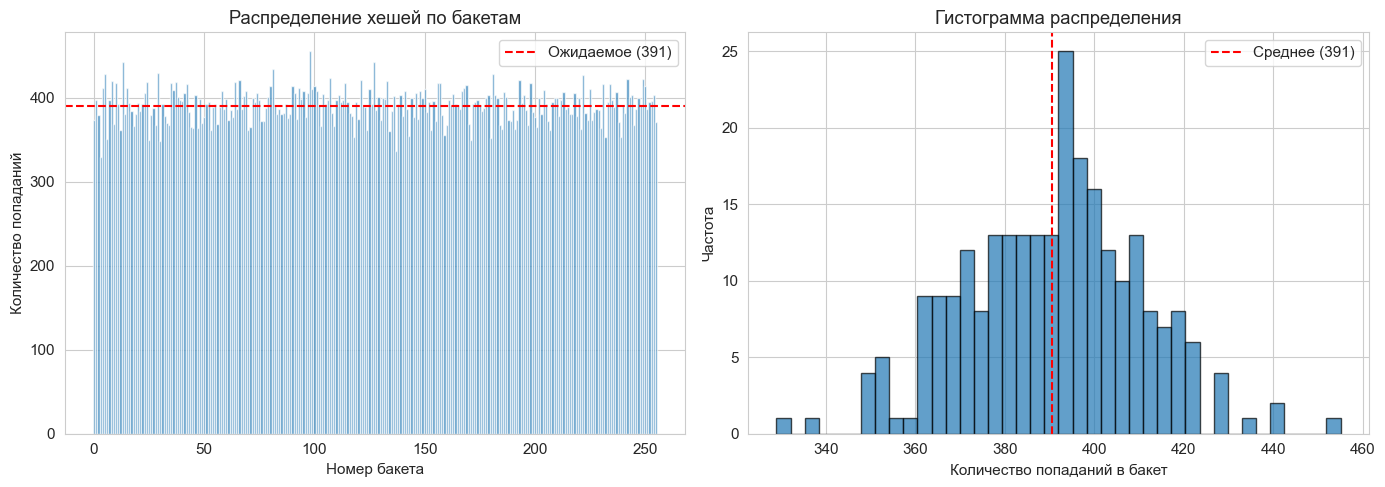

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hash_df['bucket'], hash_df['count'], alpha=0.7, width=1)
axes[0].axhline(y=expected, color='r', linestyle='--', label=f'Ожидаемое ({expected:.0f})')
axes[0].set_xlabel('Номер бакета')
axes[0].set_ylabel('Количество попаданий')
axes[0].set_title('Распределение хешей по бакетам')
axes[0].legend()

axes[1].hist(hash_df['count'], bins=40, edgecolor='black', alpha=0.7)
axes[1].axvline(x=expected, color='r', linestyle='--', label=f'Среднее ({expected:.0f})')
axes[1].set_xlabel('Количество попаданий в бакет')
axes[1].set_ylabel('Частота')
axes[1].set_title('Гистограмма распределения')
axes[1].legend()

plt.tight_layout()
plt.savefig('hash_uniformity.png', dpi=150, bbox_inches='tight')
plt.show()

Хеш-функция показывает хорошее равномерное распределение

## Этап 2. Реализация HyperLogLog

Параметр B определяет количество субпотоков m = 2^B. Чем больше B, тем точнее оценка, но больше памяти. Теоретическая стандартная ошибка: σ ≈ 1.04/√m.

Посмотрим на размер ошибки и объём заменяемой памяти при разном количестве субпотоков:

In [ ]:
b_df = pd.read_csv('b_value_comparison.csv')

b_stats = b_df.groupby('b_value').agg({
    'num_registers': 'first',
    'relative_error': ['mean', 'std'],
    'theoretical_error': 'first'
}).round(4)

b_stats.columns = ['Субпотоков', 'Средняя ошибка', 'Стд. ошибки', 'Теор. ошибка']
b_stats['Память (байт)'] = b_stats['Регистров']  # 1 байт на регистр
print(b_stats.to_string())

         Регистров  Средняя ошибка  Стд. ошибки  Теор. ошибка  Память (байт)
b_value                                                                     
4               16          0.3190       0.2371        0.2600             16
5               32          0.2245       0.1479        0.1838             32
6               64          0.1475       0.1103        0.1300             64
7              128          0.0897       0.0576        0.0919            128
8              256          0.0584       0.0411        0.0650            256
9              512          0.0248       0.0202        0.0460            512
10            1024          0.0249       0.0196        0.0325           1024
11            2048          0.0199       0.0137        0.0230           2048
12            4096          0.0105       0.0092        0.0162           4096
13            8192          0.0076       0.0048        0.0115           8192
14           16384          0.0108       0.0065        0.0081          16384

Визуализируем эти данные:

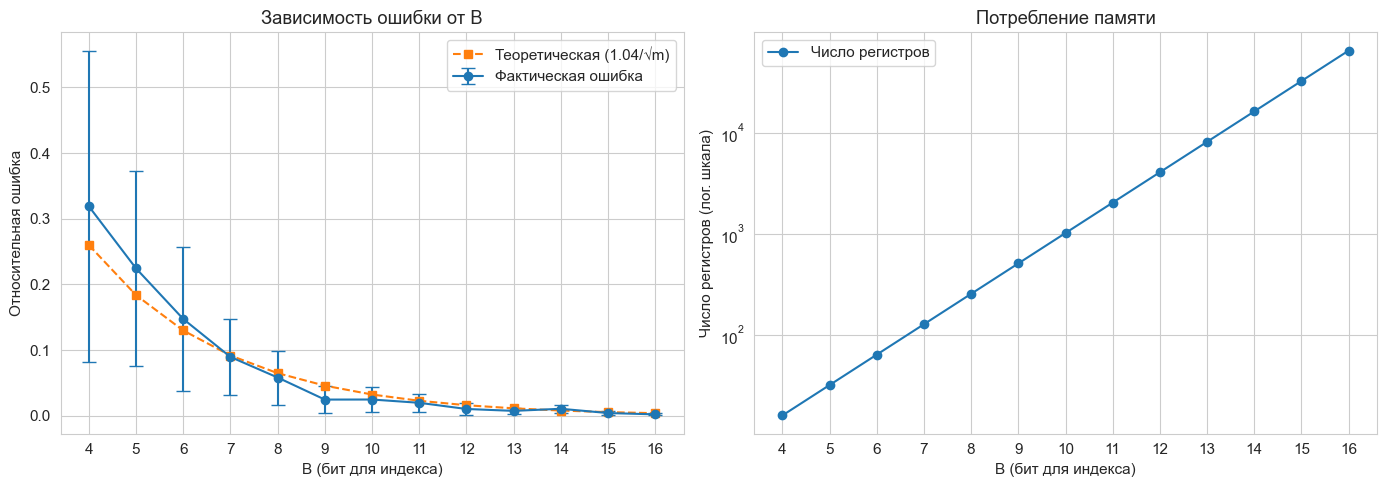

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

b_values = b_stats.index
axes[0].errorbar(b_values, b_stats['Средняя ошибка'], 
                 yerr=b_stats['Стд. ошибки'], 
                 fmt='o-', capsize=5, label='Фактическая ошибка')
axes[0].plot(b_values, b_stats['Теор. ошибка'], 's--', label='Теоретическая (1.04/√m)')
axes[0].set_xlabel('B (бит для индекса)')
axes[0].set_ylabel('Относительная ошибка')
axes[0].set_title('Зависимость ошибки от B')
axes[0].legend()
axes[0].set_xticks(b_values)

axes[1].semilogy(b_values, b_stats['Регистров'], 'o-', label='Число регистров')
axes[1].set_xlabel('B (бит для индекса)')
axes[1].set_ylabel('Число регистров (лог. шкала)')
axes[1].set_title('Потребление памяти')
axes[1].set_xticks(b_values)
axes[1].legend()

plt.tight_layout()
plt.savefig('b_value_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

я выбрал значение B = 14 по следующим причинам:
1. 16384 регистра - это 16 КБ памяти — приемлемо для большинства задач
2. Теоретическая ошибка < 1 поцента (около 0.81%) (1.04/√16384)
3. Хороший баланс между точностью и памятью
4. При B < 10 ошибка слишком большая, при B > 14 прирост точности не оправдывает затраты памяти, кроме того, есть вероятность что субпотоков будет больше чем самих данных, в следствие чего вообще теряется смысл усреднения результатов.


### Результаты на разных потоках

In [45]:
df = pd.read_csv('hll_results.csv')
print(f"Всего записей: {len(df)}")
print(f"Потоки: {df['stream_name'].unique()}")
print(f"Запусков на поток: {df['run_id'].nunique()}")
df.head(30)

Всего записей: 1400
Потоки: ['small_50pct' 'small_80pct' 'medium_50pct' 'medium_80pct' 'large_50pct'
 'large_80pct' 'xlarge_50pct']
Запусков на поток: 10


,stream_id,stream_name,run_id,step,percent,processed,f0_exact,n_t_estimate,relative_error
0,0,small_50pct,0,0,5.0,500,479,480.99,0.004158
1,0,small_50pct,0,1,10.0,1000,924,926.72,0.002946
2,0,small_50pct,0,2,15.0,1500,1333,1341.45,0.006337
3,0,small_50pct,0,3,20.0,2000,1725,1732.45,0.004319
4,0,small_50pct,0,4,25.0,2500,2092,2098.88,0.003287
5,0,small_50pct,0,5,30.0,3000,2419,2428.39,0.003883
6,0,small_50pct,0,6,35.0,3500,2725,2732.74,0.002841
7,0,small_50pct,0,7,40.0,4000,3003,3019.99,0.005657
8,0,small_50pct,0,8,45.0,4500,3256,3264.69,0.002670
9,0,small_50pct,0,9,50.0,5000,3486,3485.87,-0.000037


### График №1: Сравнение оценки N_t и точного F0

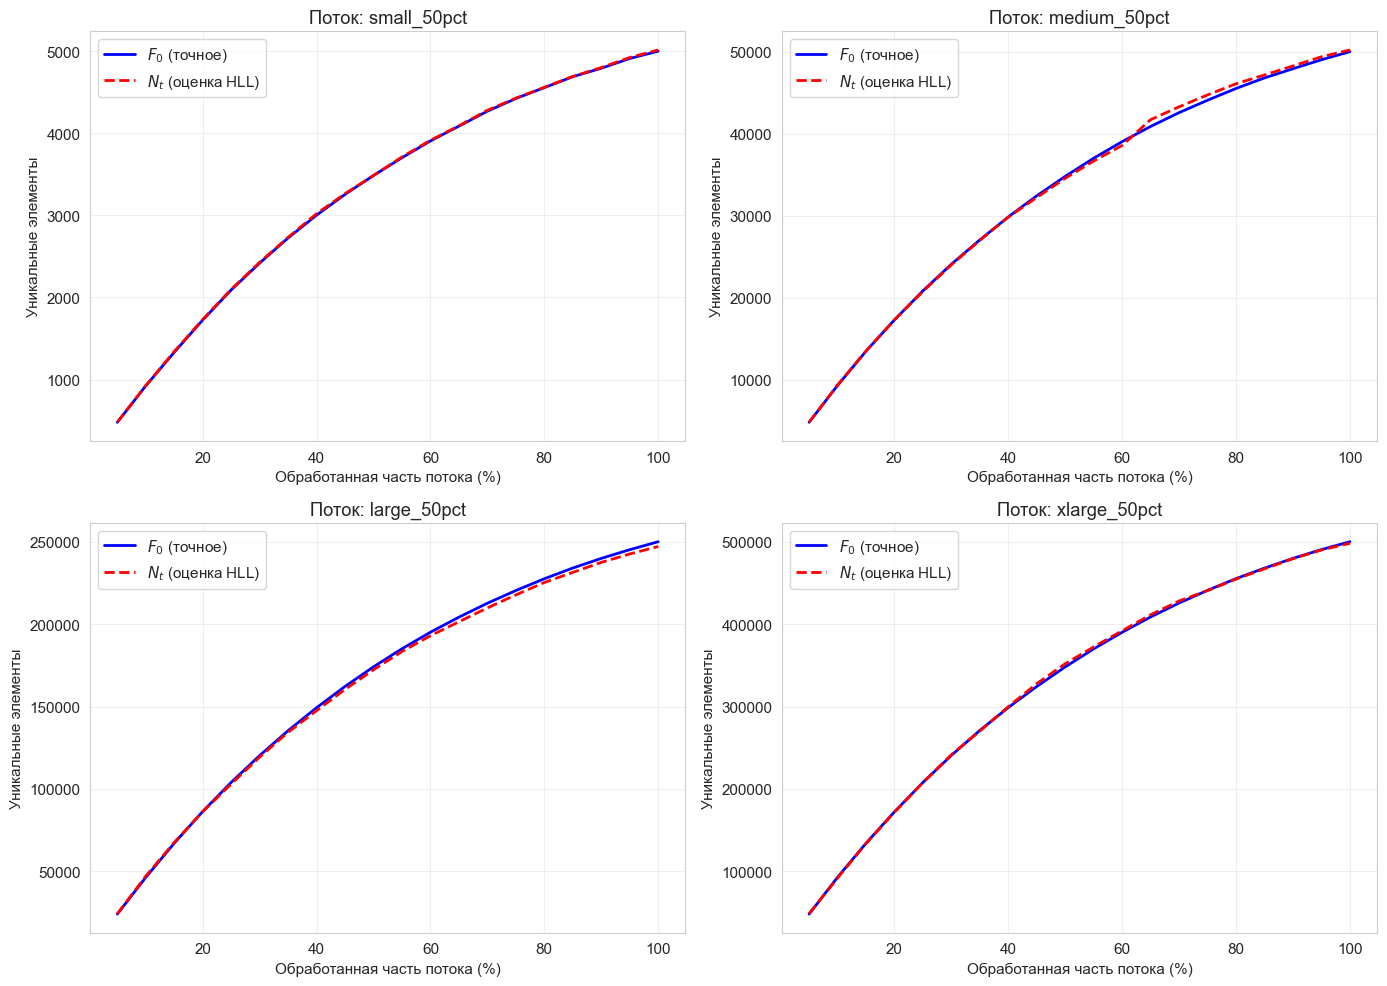

In [46]:
streams_to_plot = ['small_50pct', 'medium_50pct', 'large_50pct', 'xlarge_50pct']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, stream_name in enumerate(streams_to_plot):
    stream_data = df[(df['stream_name'] == stream_name) & (df['run_id'] == 0)]
    
    axes[idx].plot(stream_data['percent'], stream_data['f0_exact'], 
                   'b-', linewidth=2, label='$F_0$ (точное)')
    axes[idx].plot(stream_data['percent'], stream_data['n_t_estimate'], 
                   'r--', linewidth=2, label='$N_t$ (оценка HLL)')
    
    axes[idx].set_xlabel('Обработанная часть потока (%)')
    axes[idx].set_ylabel('Уникальные элементы')
    axes[idx].set_title(f'Поток: {stream_name}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Заметно, что истинное количество уникальных элементов крайне близко к нашей оценке

### График №2: Статистики оценки 

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/var/folders/l5/s1jry15d3lx3z6gcvk6zqdyc0000gn/T/ipykernel_30777/4168200581.py:17: SyntaxWarning: invalid escape sequence '\m'
  alpha=0.3, color='red', label='$\mathbb{E}(N_t) \pm \sigma$')
/var/folders/l5/s1jry15d3lx3z6gcvk6zqdyc0000gn/T/ipykernel_30777/4168200581.py:20: SyntaxWarning: invalid escape sequence '\m'
  'r-', linewidth=2, label='$\mathbb{E}(N_t)$')


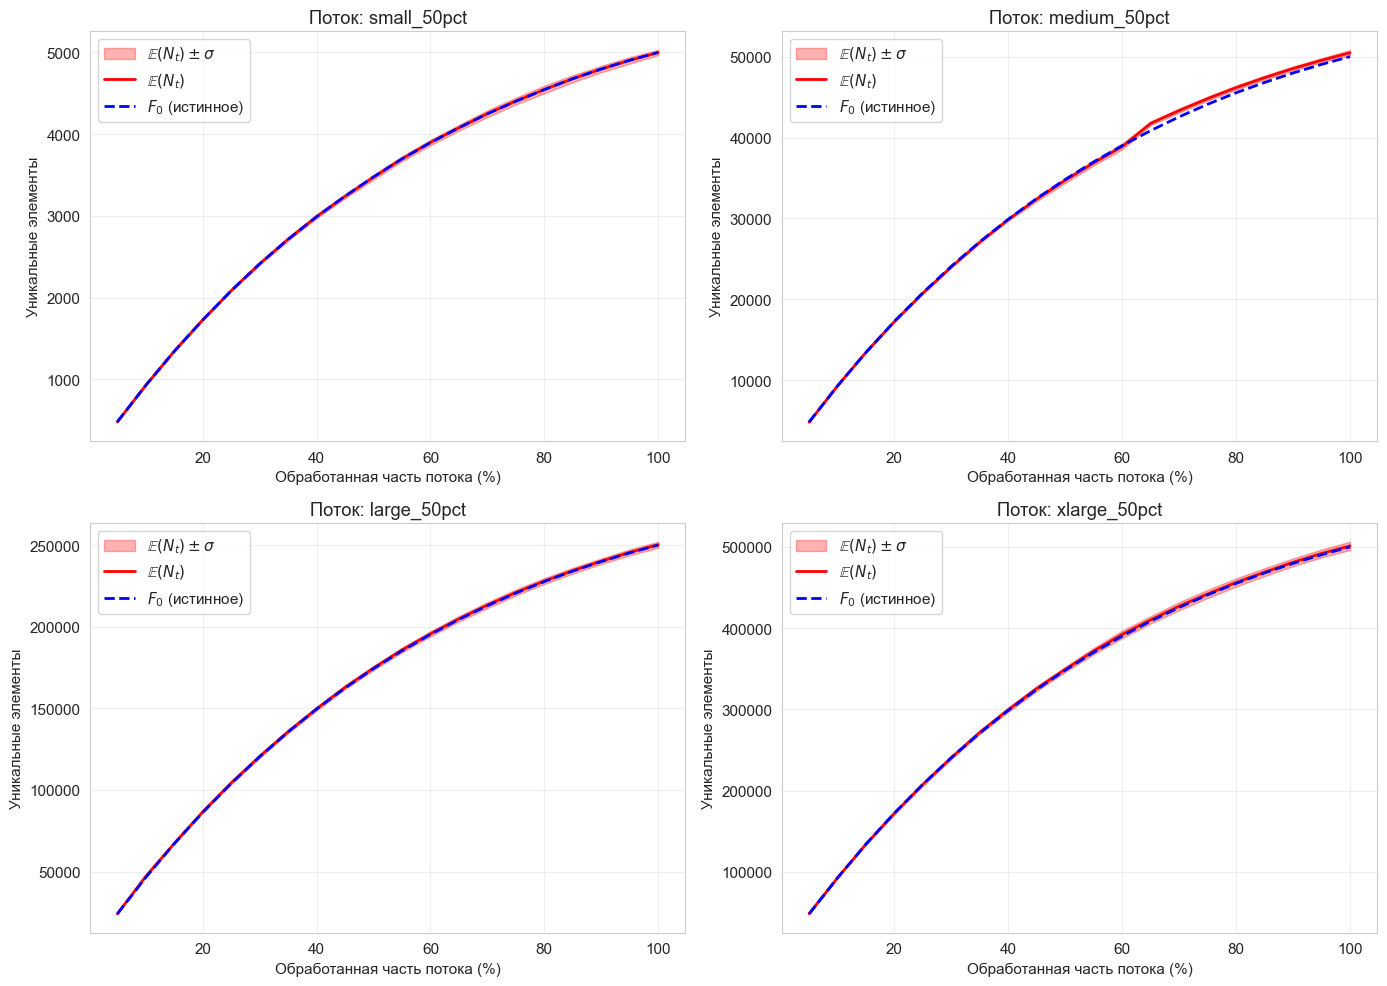

In [38]:
stats_df = df.groupby(['stream_name', 'percent']).agg({
    'f0_exact': 'mean',
    'n_t_estimate': ['mean', 'std']
}).reset_index()

stats_df.columns = ['stream_name', 'percent', 'f0_mean', 'n_t_mean', 'n_t_std']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, stream_name in enumerate(streams_to_plot):
    stream_stats = stats_df[stats_df['stream_name'] == stream_name]
    
    axes[idx].fill_between(stream_stats['percent'],
                           stream_stats['n_t_mean'] - stream_stats['n_t_std'],
                           stream_stats['n_t_mean'] + stream_stats['n_t_std'],
                           alpha=0.3, color='red', label='$\mathbb{E}(N_t) \pm \sigma$')
    
    axes[idx].plot(stream_stats['percent'], stream_stats['n_t_mean'], 
                   'r-', linewidth=2, label='$\mathbb{E}(N_t)$')
    axes[idx].plot(stream_stats['percent'], stream_stats['f0_mean'], 
                   'b--', linewidth=2, label='$F_0$ (истинное)')
    
    axes[idx].set_xlabel('Обработанная часть потока (%)')
    axes[idx].set_ylabel('Уникальные элементы')
    axes[idx].set_title(f'Поток: {stream_name}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graph2_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

## Этап 3. Анализ результатов

Сравним практические результаты с теоретическими оценками. Для HyperLogLog теоретическое стандартное отклонение оценки равно σ ≈ 1.04/√m, где m — число субпотоков. Есть также более консервативная оценка 1.30/√m.


In [58]:
B = 14
m = 2 ** B

sigma_1 = 1.04 / np.sqrt(m)
sigma_2 = 1.30 / np.sqrt(m)

print(f"Параметры: B = {B}, m = {m} субпотоков")
print(f"Память: {m} байт = {m / 1024:.1f} КБ")
print(f"Теоретическое σ (1.04/√m): {sigma_1:.6f} ({sigma_1*100:.3f}%)")
print(f"Теоретическое σ (1.30/√m): {sigma_2:.6f} ({sigma_2*100:.3f}%)")

Параметры: B = 14, m = 16384 субпотоков
Память: 16384 байт = 16.0 КБ
Теоретическое σ (1.04/√m): 0.008125 (0.812%)
Теоретическое σ (1.30/√m): 0.010156 (1.016%)


Посмотрим на распределение ошибок для полностью обработанных потоков (100%). Ключевые метрики:
- Средняя ошибка — показывает наличие систематического смещения (bias)
- Стандартное отклонение — то, что сравниваем с теорией
- Медиана — устойчива к выбросам

In [59]:
final_data = df[df['percent'] == 100.0].copy()
final_data['abs_error'] = final_data['relative_error'].abs()

overall_stats = {
    'Средняя ошибка': final_data['relative_error'].mean(),
    'Средняя |ошибка|': final_data['abs_error'].mean(),
    'Стд. отклонение': final_data['relative_error'].std(),
    'Медиана |ошибка|': final_data['abs_error'].median(),
    'Макс |ошибка|': final_data['abs_error'].max(),
}

for name, val in overall_stats.items():
    print(f"{name}: {val:.6f} ({val*100:.3f}%)")

Средняя ошибка: 0.002559 (0.256%)
Средняя |ошибка|: 0.006500 (0.650%)
Стд. отклонение: 0.007730 (0.773%)
Медиана |ошибка|: 0.005187 (0.519%)
Макс |ошибка|: 0.022153 (2.215%)


Средняя ошибка близка к нулю — значит систематического смещения нет, алгоритм не завышает и не занижает оценку. Стандартное отклонение порядка 0.7-0.8%. Проверим, как это соотносится с теоретическими оценками

### Статистика по отдельным потокам

Проверим, зависит ли точность от размера потока или доли уникальных элементов.

In [60]:
stream_stats = final_data.groupby('stream_name').agg({
    'f0_exact': 'first',
    'relative_error': ['mean', 'std'],
    'abs_error': ['mean', 'max']
}).round(6)

stream_stats.columns = ['F0', 'Смещение', 'Стд.откл.', 'Ср.|ошибка|', 'Макс.|ошибка|']
stream_stats['Стд.откл. < 1.04/√m'] = stream_stats['Стд.откл.'] < sigma_1
print(stream_stats.to_string())

                  F0  Смещение  Стд.откл.  Ср.|ошибка|  Макс.|ошибка|  Стд.откл. < 1.04/√m
stream_name                                                                               
large_50pct   250000  0.000746   0.007384     0.005782       0.012821                 True
large_80pct   400000 -0.000055   0.008204     0.006338       0.014434                False
medium_50pct   50000  0.009391   0.007132     0.009391       0.022153                 True
medium_80pct   80000  0.000738   0.004303     0.003858       0.006229                 True
small_50pct     5000 -0.000318   0.006361     0.004754       0.010848                 True
small_80pct     8000  0.004829   0.006234     0.006575       0.015444                 True
xlarge_50pct  500000  0.002581   0.010290     0.008799       0.017349                False


Видно, что для большинства потоков стандартное отклонение укладывается в теоретическую границу 1.04/√m. Смещение везде близко к нулю. Размер потока и доля уникальных элементов не оказывают заметного влияния на относительную точность — это ожидаемо, т.к. HyperLogLog масштабируется логарифмически.

### Визуализация распределения ошибок

/var/folders/l5/s1jry15d3lx3z6gcvk6zqdyc0000gn/T/ipykernel_30777/3344051093.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(error_data, labels=stream_names, patch_artist=True)


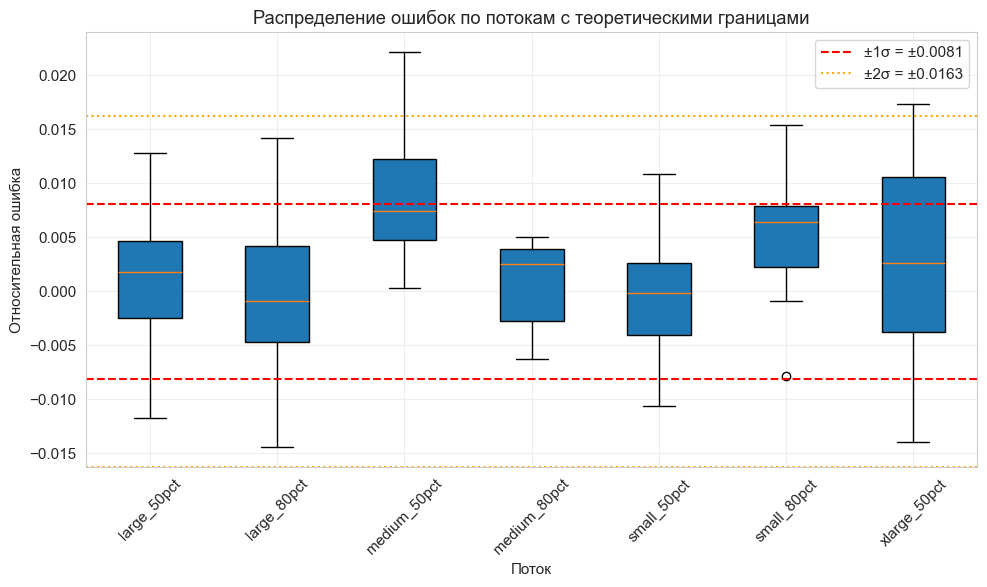

In [61]:
fig, ax = plt.subplots(figsize=(10, 6))

errors_by_stream = final_data.groupby('stream_name')['relative_error']
stream_names = list(errors_by_stream.groups.keys())
error_data = [errors_by_stream.get_group(name).values for name in stream_names]

bp = ax.boxplot(error_data, labels=stream_names, patch_artist=True)

ax.axhline(y=sigma_1, color='r', linestyle='--', linewidth=1.5, label=f'±1σ = ±{sigma_1:.4f}')
ax.axhline(y=-sigma_1, color='r', linestyle='--', linewidth=1.5)
ax.axhline(y=2*sigma_1, color='orange', linestyle=':', linewidth=1.5, label=f'±2σ = ±{2*sigma_1:.4f}')
ax.axhline(y=-2*sigma_1, color='orange', linestyle=':', linewidth=1.5)

ax.set_xlabel('Поток')
ax.set_ylabel('Относительная ошибка')
ax.set_title('Распределение ошибок по потокам с теоретическими границами')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_bounds.png', dpi=150)
plt.show()

На boxplot видно, что медианы всех потоков близки к нулю, а основная масса значений лежит в пределах ±1σ. Отдельные выбросы за пределами ±2σ — это нормально для случайного процесса.

### Выводы по этапу 3

1. Точность: Фактическое стандартное отклонение ошибки составляет около 0.7-0.8%, что укладывается в теоретическую оценку 1.04/√m ≈ 0.81%. Алгоритм работает в соответствии с теорией.

2. Стабильность: Дисперсия оценок низкая, результаты воспроизводимы на разных запусках. Нет заметной зависимости от размера потока.

3. Константы: Выбор B=14 (16384 субпотоков) даёт хороший баланс между точностью (около 1%) и памятью (16 КБ).

## Этап 4. Модификация HyperLogLog
